# Setting up

In [40]:
!pip install -qU langchain-groq

# Chat Models

In [10]:
from langchain_groq import ChatGroq
from google.colab import userdata

groq_key = userdata.get('GROQ_API_KEY')

llm = ChatGroq(
    api_key=groq_key,
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [7]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
ai_msg.content

"J'aime la programmation."

## Vision

### Input Image:

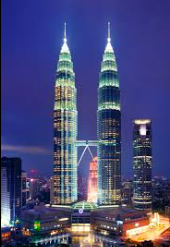

In [12]:
from langchain_groq import ChatGroq
from langchain.messages import HumanMessage

llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", api_key=groq_key)

message = HumanMessage(
    content=[
        {"type": "text", "text": "Describe this image in detail."},
        {
            "type": "image_url",
            "image_url": {"url": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQOdkknqik8hCacTe7HkB6CJmocSyYDkkU2FA&s"},
        },
    ]
)

response = llm.invoke([message])
print(response.content)

The image depicts a nighttime scene of the Petronas Twin Towers in Kuala Lumpur, Malaysia. The towers are the central focus of the image and are illuminated with a vibrant display of blue and yellow lights. The towers' sleek, modern design is accentuated by their height and the way they pierce the dark blue sky.

In front of the towers, there appears to be a large plaza or courtyard with several buildings and structures. The surrounding area is well-lit, with many lights visible on the buildings and streets. The overall atmosphere of the image is one of grandeur and modernity, capturing the essence of Kuala Lumpur as a bustling and cosmopolitan city.

The image conveys a sense of energy and activity, suggesting that the city is alive and vibrant even at night. The Petronas Twin Towers stand out as iconic landmarks, symbolizing the city's growth and development. Overall, the image presents a stunning visual representation of Kuala Lumpur's urban landscape.


# Prompts

In [41]:
!pip install -qU langchain-core langchain-community

## Basic Prompting

In [14]:
prompt = """
Answer the user's query based on the context below.
If you cannot answer the question using the
provided information answer with "I don't know".

Context: {context}
"""

In [16]:
from langchain_core.prompts import ChatPromptTemplate

# passing the template to the LangChain model
prompt_template = ChatPromptTemplate.from_messages([
    ("system", prompt),
    ("user", "{query}"),
])

In [17]:
prompt_template.input_variables

['context', 'query']

In [18]:
prompt_template.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='\nAnswer the user\'s query based on the context below.\nIf you cannot answer the question using the\nprovided information answer with "I don\'t know".\n\nContext: {context}\n'), additional_kwargs={}),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['query'], input_types={}, partial_variables={}, template='{query}'), additional_kwargs={})]

## Invoking our LLM with Templates

### Pipelines wuth LCEL

In [19]:
pipeline = (
    {
        "query": lambda x: x["query"],
        "context": lambda x: x["context"]
    }
    | prompt_template
    | llm
)

In [20]:
context = """Aurelio AI is an AI company developing tooling for AI
engineers. Their focus is on language AI with the team having strong
expertise in building AI agents and a strong background in
information retrieval.

The company is behind several open source frameworks, most notably
Semantic Router and Semantic Chunkers. They also have an AI
Platform providing engineers with tooling to help them build with
AI. Finally, the team also provides development services to other
organizations to help them bring their AI tech to market.

Aurelio AI became LangChain Experts in September 2024 after a long
track record of delivering AI solutions built with the LangChain
ecosystem."""

query = "what does Aurelio AI do?"

In [21]:
pipeline.invoke({"query": query, "context": context})

AIMessage(content='Aurelio AI develops tooling for AI engineers, with a focus on language AI. They provide:\n\n1. Open-source frameworks, including Semantic Router and Semantic Chunkers.\n2. An AI Platform with tooling to help engineers build with AI.\n3. Development services to help other organizations bring their AI technology to market.\n\nThey specialize in building AI agents and have a strong background in information retrieval.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 188, 'total_tokens': 269, 'completion_time': 0.184537848, 'completion_tokens_details': None, 'prompt_time': 0.006893681, 'prompt_tokens_details': None, 'queue_time': 0.020591898, 'total_time': 0.191431529}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f08cd12a81', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3517-3ba4-7740-bfe5-45db3ea16067-0', tool

## Few Shot Prompting

In [22]:
example_prompt = ChatPromptTemplate.from_messages([
    ("human", "{input}"),
    ("ai", "{output}"),
])

In [23]:
examples = [
    {"input": "Here is query #1", "output": "Here is the answer #1"},
    {"input": "Here is query #2", "output": "Here is the answer #2"},
    {"input": "Here is query #3", "output": "Here is the answer #3"},
]

In [24]:
from langchain_core.prompts import FewShotChatMessagePromptTemplate

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)
# here is the formatted prompt
print(few_shot_prompt.format())

Human: Here is query #1
AI: Here is the answer #1
Human: Here is query #2
AI: Here is the answer #2
Human: Here is query #3
AI: Here is the answer #3


In [25]:
new_system_prompt = """
Answer the user's query based on the context below.
If you cannot answer the question using the
provided information answer with "I don't know".

Always answer in markdown format. When doing so please
provide headers, short summaries, follow with bullet
points, then conclude.

Context: {context}
"""

prompt_template.messages[0].prompt.template = new_system_prompt

out = pipeline.invoke({"query": query, "context": context}).content
print(out)

## Overview of Aurelio AI
Aurelio AI is an AI company that develops tooling for AI engineers, with a focus on language AI.

## Summary
The company provides various services and tools to support AI engineers and organizations in building and implementing AI solutions.

## Key Activities:
* Develops open-source frameworks, including:
	+ Semantic Router
	+ Semantic Chunkers
* Offers an AI Platform with tooling for engineers to build with AI
* Provides development services to help organizations bring their AI technology to market
* Specializes in building AI agents and information retrieval

## Expertise:
* LangChain ecosystem
* Language AI
* AI agent development
* Information retrieval

## Conclusion
Aurelio AI is a comprehensive AI company that supports AI engineers and organizations through its tooling, frameworks, and development services, with a strong focus on language AI and the LangChain ecosystem.


### Another example

In [26]:
examples = [
    {
        "input": "Can you explain gravity?",
        "output": (
            "## Gravity\n\n"
            "Gravity is one of the fundamental forces in the universe.\n\n"
            "### Discovery\n\n"
            "* Gravity was first discovered by Sir Isaac Newton in the late 17th century.\n"
            "* It was said that Newton theorized about gravity after seeing an apple fall from a tree.\n\n"
            "### In General Relativity\n\n"
            "* Gravity is described as the curvature of spacetime.\n"
            "* The more massive an object is, the more it curves spacetime.\n"
            "* This curvature is what causes objects to fall towards each other.\n\n"
            "### Gravitons\n\n"
            "* Gravitons are hypothetical particles that mediate the force of gravity.\n"
            "* They have not yet been detected.\n\n"
            "**To conclude**, Gravity is a fascinating topic and has been studied extensively since the time of Newton.\n\n"
        )
    },
    {
        "input": "What is the capital of France?",
        "output": (
            "## France\n\n"
            "The capital of France is Paris.\n\n"
            "### Origins\n\n"
            "* The name Paris comes from the Latin word \"Parisini\" which referred to a Celtic people living in the area.\n"
            "* The Romans named the city Lutetia, which means \"the place where the river turns\".\n"
            "* The city was renamed Paris in the 3rd century BC by the Celtic-speaking Parisii tribe.\n\n"
            "**To conclude**, Paris is highly regarded as one of the most beautiful cities in the world and is one of the world's greatest cultural and economic centres.\n\n"
        )
    }
]

In [27]:
few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)

### display the prompt now

In [29]:
from IPython.display import display, Markdown

out = few_shot_prompt.format()

display(Markdown(out))

Human: Can you explain gravity?
AI: ## Gravity

Gravity is one of the fundamental forces in the universe.

### Discovery

* Gravity was first discovered by Sir Isaac Newton in the late 17th century.
* It was said that Newton theorized about gravity after seeing an apple fall from a tree.

### In General Relativity

* Gravity is described as the curvature of spacetime.
* The more massive an object is, the more it curves spacetime.
* This curvature is what causes objects to fall towards each other.

### Gravitons

* Gravitons are hypothetical particles that mediate the force of gravity.
* They have not yet been detected.

**To conclude**, Gravity is a fascinating topic and has been studied extensively since the time of Newton.


Human: What is the capital of France?
AI: ## France

The capital of France is Paris.

### Origins

* The name Paris comes from the Latin word "Parisini" which referred to a Celtic people living in the area.
* The Romans named the city Lutetia, which means "the place where the river turns".
* The city was renamed Paris in the 3rd century BC by the Celtic-speaking Parisii tribe.

**To conclude**, Paris is highly regarded as one of the most beautiful cities in the world and is one of the world's greatest cultural and economic centres.



In [30]:
few_shot_prompt

FewShotChatMessagePromptTemplate(examples=[{'input': 'Can you explain gravity?', 'output': '## Gravity\n\nGravity is one of the fundamental forces in the universe.\n\n### Discovery\n\n* Gravity was first discovered by Sir Isaac Newton in the late 17th century.\n* It was said that Newton theorized about gravity after seeing an apple fall from a tree.\n\n### In General Relativity\n\n* Gravity is described as the curvature of spacetime.\n* The more massive an object is, the more it curves spacetime.\n* This curvature is what causes objects to fall towards each other.\n\n### Gravitons\n\n* Gravitons are hypothetical particles that mediate the force of gravity.\n* They have not yet been detected.\n\n**To conclude**, Gravity is a fascinating topic and has been studied extensively since the time of Newton.\n\n'}, {'input': 'What is the capital of France?', 'output': '## France\n\nThe capital of France is Paris.\n\n### Origins\n\n* The name Paris comes from the Latin word "Parisini" which refe

In [31]:
prompt_template = ChatPromptTemplate.from_messages([
    ("system", new_system_prompt),
    few_shot_prompt,
    ("user", "{query}"),
])

In [33]:
prompt_template.input_variables

['context', 'query']

In [34]:
pipeline = prompt_template | llm
out = pipeline.invoke({"query": query, "context": context}).content
display(Markdown(out))

## Aurelio AI

Aurelio AI is an AI company that develops tooling for AI engineers.

### Focus and Expertise

* The company's focus is on language AI.
* The team has strong expertise in building AI agents and a strong background in information retrieval.

### Products and Services

* Aurelio AI is behind several open-source frameworks, including:
  * Semantic Router
  * Semantic Chunkers
* The company also offers an AI Platform that provides engineers with tooling to help them build with AI.
* Additionally, the team provides development services to other organizations to help them bring their AI technology to market.

### Partnerships

* Aurelio AI became LangChain Experts in September 2024, recognizing their long track record of delivering AI solutions built with the LangChain ecosystem.

**To conclude**, Aurelio AI is a leading AI company that provides innovative tooling and services for AI engineers and organizations.

## COT Prompt

In [35]:
no_cot_system_prompt = """
Be a helpful assistant and answer the user's question.

You MUST answer the question directly without any other
text or explanation.
"""

no_cot_prompt_template = ChatPromptTemplate.from_messages([
    ("system", no_cot_system_prompt),
    ("user", "{query}"),
])

In [36]:
query = (
    "How many keystrokes are needed to type the numbers from 1 to 500?"
)

no_cot_pipeline = no_cot_prompt_template | llm
no_cot_result = no_cot_pipeline.invoke({"query": query}).content
print(no_cot_result)

To type the numbers from 1 to 500, we need to consider the number of keystrokes required for each number.

## Step 1: Calculate keystrokes for numbers 1 to 9
Numbers 1 to 9 are single-digit numbers, requiring 1 keystroke each. There are 9 numbers in this range, so the total keystrokes needed are 9.

## 2: Calculate keystrokes for numbers 10 to 99
Numbers 10 to 99 are two-digit numbers, requiring 2 keystrokes each. There are 90 numbers in this range (99 - 10 + 1 = 90), so the total keystrokes needed are 90 * 2 = 180.

## 3: Calculate keystrokes for numbers 100 to 500
Numbers 100 to 500 are three-digit numbers, requiring 3 keystrokes each. There are 401 numbers in this range (500 - 100 + 1 = 401), so the total keystrokes needed are 401 * 3 = 1203.

## 4: Sum the keystrokes for all ranges
Total keystrokes = keystrokes for 1 to 9 + keystrokes for 10 to 99 + keystrokes for 100 to 500 = 9 + 180 + 1203 = 1392.

The final answer is 1392.


In [37]:
# Define the chain-of-thought prompt template
cot_system_prompt = """
Be a helpful assistant and answer the user's question.

To answer the question, you must:

- List systematically and in precise detail all
  subproblems that need to be solved to answer the
  question.
- Solve each sub problem INDIVIDUALLY and in sequence.
- Finally, use everything you have worked through to
  provide the final answer.
"""

cot_prompt_template = ChatPromptTemplate.from_messages([
    ("system", cot_system_prompt),
    ("user", "{query}"),
])

cot_pipeline = cot_prompt_template | llm

In [38]:
cot_result = cot_pipeline.invoke({"query": query}).content
display(Markdown(cot_result))

## Step 1: Identify the pattern for keystrokes for single-digit numbers
To type the numbers from 1 to 9, we need 9 keystrokes since each number requires one keystroke.

## 2: Identify the pattern for keystrokes for double-digit numbers
For numbers from 10 to 99, there are 90 numbers. Each of these numbers requires 2 keystrokes. So, the total keystrokes for double-digit numbers are 90 * 2 = 180 keystrokes.

## 3: Identify the pattern for keystrokes for triple-digit numbers
For numbers from 100 to 500, there are 401 numbers (since 500 - 100 + 1 = 401). Each of these numbers requires 3 keystrokes. So, the total keystrokes for triple-digit numbers are 401 * 3 = 1203 keystrokes.

## 4: Calculate the total keystrokes needed
To find the total keystrokes needed to type the numbers from 1 to 500, we add the keystrokes for single-digit, double-digit, and triple-digit numbers. Total keystrokes = 9 (for 1-9) + 180 (for 10-99) + 1203 (for 100-500) = 9 + 180 + 1203 = 1392.

The final answer is: $\boxed{1392}$

# LangChain Expression Language (LCEL)

## Traditional LLMChain

In [44]:
from langchain_core.prompts import PromptTemplate

prompt_template = "Give me a small report on {topic}"

prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_template
)

In [45]:
llm_out = llm.invoke("Hello there")
llm_out

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 12, 'total_tokens': 34, 'completion_time': 0.049873081, 'completion_tokens_details': None, 'prompt_time': 4.8719e-05, 'prompt_tokens_details': None, 'queue_time': 0.073101652, 'total_time': 0.0499218}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f08cd12a81', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e35eb-3750-72a1-9430-e96c3c35482e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 22, 'total_tokens': 34})

In [47]:
from langchain_core.output_parsers import StrOutputParser

output_parser = StrOutputParser()

In [48]:
out = output_parser.invoke(llm_out)
out

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

Through the `LLMChain` class we can place each of our components into a linear `chain`.

In [49]:
from langchain.chains import LLMChain

chain = LLMChain(prompt=prompt, llm=llm, output_parser=output_parser)

result = chain.invoke("retrieval augmented generation")
result

ModuleNotFoundError: No module named 'langchain.chains'

It got an error because it's completely depracated, but that's the code to do it before

In [ ]:
from IPython.display import display, Markdown

display(Markdown(result["text"]))

## LCEL

In [50]:
lcel_chain = prompt | llm | output_parser

In [51]:
result = lcel_chain.invoke("retrieval augmented generation")
result

"Here's a small report on Retrieval-Augmented Generation (RAG):\n\n**Introduction**\n\nRetrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) and artificial intelligence (AI) to improve the quality and accuracy of generated text. RAG combines the strengths of retrieval-based and generation-based approaches to text production.\n\n**How RAG Works**\n\nThe RAG framework consists of two main components:\n\n1. **Retriever**: This module retrieves relevant documents or passages from a large corpus or database based on a given input prompt or query.\n2. **Generator**: This module takes the retrieved documents and uses them to generate a response or text.\n\nThe process works as follows:\n\n1. Input prompt or query is passed to the retriever.\n2. The retriever searches the corpus and retrieves a set of relevant documents or passages.\n3. The retrieved documents are then passed to the generator.\n4. The generator uses the retrieved documents to generate a 

In [52]:
display(Markdown(result))

Here's a small report on Retrieval-Augmented Generation (RAG):

**Introduction**

Retrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) and artificial intelligence (AI) to improve the quality and accuracy of generated text. RAG combines the strengths of retrieval-based and generation-based approaches to text production.

**How RAG Works**

The RAG framework consists of two main components:

1. **Retriever**: This module retrieves relevant documents or passages from a large corpus or database based on a given input prompt or query.
2. **Generator**: This module takes the retrieved documents and uses them to generate a response or text.

The process works as follows:

1. Input prompt or query is passed to the retriever.
2. The retriever searches the corpus and retrieves a set of relevant documents or passages.
3. The retrieved documents are then passed to the generator.
4. The generator uses the retrieved documents to generate a response or text.

**Advantages**

RAG offers several advantages over traditional generation-based approaches:

1. **Improved accuracy**: By retrieving relevant documents, RAG can ensure that the generated text is more accurate and informed.
2. **Increased efficiency**: RAG can reduce the need for large amounts of training data, as the retriever can provide relevant information from existing sources.
3. **Better handling of rare or out-of-vocabulary words**: RAG can handle rare or out-of-vocabulary words by retrieving documents that contain these words.

**Applications**

RAG has various applications in NLP and AI, including:

1. **Question answering**: RAG can be used to answer questions by retrieving relevant documents and generating a response.
2. **Text summarization**: RAG can be used to summarize long documents by retrieving relevant passages and generating a summary.
3. **Chatbots and conversational AI**: RAG can be used to improve the responses generated by chatbots and conversational AI systems.

**Challenges and Future Directions**

While RAG has shown promising results, there are several challenges and future directions to explore:

1. **Improving retriever performance**: Developing more accurate and efficient retrievers is crucial to improving RAG performance.
2. **Integrating RAG with other NLP tasks**: RAG can be integrated with other NLP tasks, such as sentiment analysis and entity recognition.
3. **Handling multi-modal input**: RAG can be extended to handle multi-modal input, such as images and videos.

Overall, Retrieval-Augmented Generation is a powerful technique that combines the strengths of retrieval-based and generation-based approaches to text production. Its applications in NLP and AI are vast, and ongoing research aims to improve its performance and efficiency.

## LCEL `RunnableLambda`

The `RunnableLambda` class is LangChain's built-in method for constructing a _runnable_ object from a function. That is, it does the same thing as the custom `Runnable` class we created earlier. Let's try it out with the same functions as before.

In [54]:
def add_five(x):
    return x+5

def sub_five(x):
    return x-5

def mul_five(x):
    return x*5

In [55]:
from langchain_core.runnables import RunnableLambda

add_five_runnable = RunnableLambda(add_five)
sub_five_runnable = RunnableLambda(sub_five)
mul_five_runnable = RunnableLambda(mul_five)

In [56]:
chain = add_five_runnable | sub_five_runnable | mul_five_runnable

In [57]:
chain.invoke(3)

15

Now we want to try something a little more testing, so this time we will generate a report, and we will try and edit that report using this functionallity.

In [58]:
prompt_str = "give me a small report about {topic}"
prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_str
)

In [59]:
chain = prompt | llm | output_parser

In [60]:
result = chain.invoke("AI")
display(Markdown(result))

Here's a brief report on AI:

**Introduction**

Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. AI has rapidly evolved in recent years, transforming numerous industries and aspects of our lives.

**Key Applications of AI**

1. **Virtual Assistants**: AI-powered virtual assistants, like Siri, Alexa, and Google Assistant, can perform tasks, provide information, and control smart home devices.
2. **Image and Speech Recognition**: AI algorithms can recognize and classify images, and also transcribe speech into text, enabling applications like facial recognition, object detection, and voice-to-text systems.
3. **Natural Language Processing (NLP)**: AI-powered NLP enables computers to understand, interpret, and generate human language, facilitating applications like chatbots, language translation, and sentiment analysis.
4. **Predictive Analytics**: AI algorithms can analyze large datasets to make predictions, identify patterns, and optimize business processes, commonly used in industries like finance, healthcare, and marketing.

**Benefits and Impact**

1. **Increased Efficiency**: AI automates repetitive and mundane tasks, freeing up human resources for more strategic and creative work.
2. **Improved Accuracy**: AI systems can analyze vast amounts of data, reducing errors and improving decision-making.
3. **Enhanced Customer Experience**: AI-powered chatbots and virtual assistants provide 24/7 customer support, improving customer satisfaction and engagement.

**Challenges and Concerns**

1. **Job Displacement**: The increasing use of AI raises concerns about job displacement, particularly for roles that involve repetitive or routine tasks.
2. **Bias and Fairness**: AI systems can perpetuate biases and discrimination if trained on biased data, highlighting the need for fairness and transparency in AI development.
3. **Security and Ethics**: AI systems can be vulnerable to cyber attacks, and their development raises ethical concerns, such as accountability, transparency, and human oversight.

**Future Outlook**

As AI continues to evolve, we can expect significant advancements in areas like:

1. **Edge AI**: AI systems that can operate on edge devices, like smartphones and smart home devices, without relying on cloud connectivity.
2. **Explainable AI**: AI systems that can provide transparent and interpretable explanations for their decisions and actions.
3. **Human-AI Collaboration**: AI systems that can collaborate with humans, augmenting human capabilities and enhancing productivity.

Overall, AI has the potential to transform numerous industries and aspects of our lives, but it also raises important challenges and concerns that need to be addressed.

## LCEL `RunnableParallel` and `RunnablePassthrough`

LCEL provides us with various `Runnable` classes that allow us to control the flow of data and execution order through our chains. Two of these are `RunnableParallel` and `RunnablePassthrough`.

* `RunnableParallel` — allows us to run multiple `Runnable` instances in parallel. Acting almost as a Y-fork in the chain.

* `RunnablePassthrough` — allows us to pass through a variable to the next `Runnable` without modification.



> The following code I can't run it because I'm out of API balance :)



In [61]:
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import DocArrayInMemorySearch

embedding = OpenAIEmbeddings()

vecstore_a = DocArrayInMemorySearch.from_texts(
    [
        "half the info is here",
        "DeepSeek-V3 was released in December 2024"
    ],
    embedding=embedding
)
vecstore_b = DocArrayInMemorySearch.from_texts(
    [
        "the other half of the info is here",
        "the DeepSeek-V3 LLM is a mixture of experts model with 671B parameters"
    ],
    embedding=embedding
)

In [ ]:
prompt_str = """Using the context provided, answer the user's question.
Context:
{context_a}
{context_b}
"""

In [ ]:
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(prompt_str),
    HumanMessagePromptTemplate.from_template("{question}")
])

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

retriever_a = vecstore_a.as_retriever()
retriever_b = vecstore_b.as_retriever()

retrieval = RunnableParallel(
    {
        "context_a": retriever_a, "context_b": retriever_b, "question": RunnablePassthrough()
    }
)

The chain we'll be constructing will look something like this:

![](https://github.com/aurelio-labs/langchain-course/blob/main/assets/lcel-flow.png?raw=1)

In [ ]:
chain = retrieval | prompt | llm | output_parser

In [ ]:
result = chain.invoke(
    "what architecture does the model DeepSeek released in december use?"
)
result

With that we've seen how we can use `RunnableParallel` and `RunnablePassthrough` to control the flow of data and execution order through our chains.

---